In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import bs4 
import itertools
from matplotlib import colors
from matplotlib.ticker import PercentFormatter

In [3]:
df = pd.read_csv("steam_proper.csv", low_memory=False)


In [4]:
import datetime
df2 = df.copy()
#Date Cleaning
df2['release_date'] = pd.to_datetime(df2['release_date'], errors='coerce')
df2['release_year']= df2['release_date'].dt.year
#print(df2['release_year'])
df2['release_year']


0        2000
1        2003
2        1999
3        1998
4        2004
         ... 
26863    2019
26864    2019
26865    2019
26866    2019
26867    2019
Name: release_year, Length: 26868, dtype: int32

In [5]:
#Platforms:
df2['platforms'].dtype
df2['platforms'] = df2['platforms'].str.split(';')
df2['windows_sup'] = df2['platforms'].apply(lambda x: 1 if 'windows' in x else 0)
df2['mac_sup'] = df2['platforms'].apply(lambda x: 1 if 'mac' in x else 0)
df2['linux_sup'] = df2['platforms'].apply(lambda x: 1 if 'linux' in x else 0)
df2

,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,...,word_game,world_war_i,world_war_ii,wrestling,zombies,e_sports,release_year,windows_sup,mac_sup,linux_sup
0,10,Counter-Strike,2000-11-01,1,Valve,Valve,"[windows, mac, linux]",0,Multi-player;Online Multi-Player;Local Multi-P...,Action,...,0,0,0,0,0,550,2000,1,1,1
1,30,Day of Defeat,2003-05-01,1,Valve,Valve,"[windows, mac, linux]",0,Multi-player;Valve Anti-Cheat enabled,Action,...,0,5,122,0,0,0,2003,1,1,1
2,50,Half-Life: Opposing Force,1999-11-01,1,Gearbox Software,Valve,"[windows, mac, linux]",0,Single-player;Multi-player;Valve Anti-Cheat en...,Action,...,0,0,0,0,0,0,1999,1,1,1
3,70,Half-Life,1998-11-08,1,Valve,Valve,"[windows, mac, linux]",0,Single-player;Multi-player;Online Multi-Player...,Action,...,0,0,0,0,0,0,1998,1,1,1
4,80,Counter-Strike: Condition Zero,2004-03-01,1,Valve,Valve,"[windows, mac, linux]",0,Single-player;Multi-player;Valve Anti-Cheat en...,Action,...,0,0,0,0,0,0,2004,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26863,1065230,Room of Pandora,2019-04-24,1,SHEN JIAWEI,SHEN JIAWEI,[windows],0,Single-player;Steam Achievements,Adventure;Casual;Indie,...,0,0,0,0,0,0,2019,1,0,0
26864,1065570,Cyber Gun,2019-04-23,1,Semyon Maximov,BekkerDev Studio,[windows],0,Single-player,Action;Adventure;Indie,...,0,0,0,0,0,0,2019,1,0,0
26865,1065650,Super Star Blast,2019-04-24,1,EntwicklerX,EntwicklerX,[windows],0,Single-player;Multi-player;Co-op;Shared/Split ...,Action;Casual;Indie,...,0,0,0,0,0,0,2019,1,0,0
26866,1066700,New Yankee 7: Deer Hunters,2019-04-17,1,Yustas Game Studio,Alawar Entertainment,"[windows, mac]",0,Single-player;Steam Cloud,Adventure;Casual;Indie,...,0,0,0,0,0,0,2019,1,1,0


In [ ]:
import itertools

#Genres
df2['genres'] = df2['genres'].str.split(';')
unique_gen = np.unique([*itertools.chain.from_iterable(df2['genres'])])
print(unique_gen)

for i in unique_gen:
    df2[i+"_genre"] = df2['genres'].apply(lambda x: 1 if i in x else 0)

['Accounting' 'Action' 'Adventure' 'Animation & Modeling'
 'Audio Production' 'Casual' 'Design & Illustration' 'Documentary'
 'Early Access' 'Education' 'Free to Play' 'Game Development' 'Gore'
 'Indie' 'Massively Multiplayer' 'Nudity' 'Photo Editing' 'RPG' 'Racing'
 'Sexual Content' 'Simulation' 'Software Training' 'Sports' 'Strategy'
 'Tutorial' 'Utilities' 'Video Production' 'Violent' 'Web Publishing']


In [7]:
#Categories:
df2['categories'] = df2['categories'].str.split(';')
unique_cat = np.unique([*itertools.chain.from_iterable(df2['categories'])])
print(unique_cat)

for i in unique_cat:
    df2[i+"_cat"] = df2['categories'].apply(lambda x: 1 if i in x else 0)

['Captions available' 'Co-op' 'Commentary available'
 'Cross-Platform Multiplayer' 'Full controller support' 'In-App Purchases'
 'Includes Source SDK' 'Includes level editor' 'Local Co-op'
 'Local Multi-Player' 'MMO' 'Mods' 'Mods (require HL2)' 'Multi-player'
 'Online Co-op' 'Online Multi-Player' 'Partial Controller Support'
 'Shared/Split Screen' 'Single-player' 'Stats' 'Steam Achievements'
 'Steam Cloud' 'Steam Leaderboards' 'Steam Trading Cards'
 'Steam Turn Notifications' 'Steam Workshop' 'SteamVR Collectibles'
 'VR Support' 'Valve Anti-Cheat enabled']


In [ ]:
df2.to_csv('steam_edit.csv')

In [9]:
tech_spec = pd.read_csv('tech_spec_cleaned (1).csv')

In [19]:
#merged = pd.merge(df2,tech_spec)
merged

,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,...,Valve Anti-Cheat enabled_cat,Unnamed: 0,cleaned,processor_Ghz,RAM_mb,GPU_mb,internet_required,storage_mb,cpu_source,tier
0,10,Counter-Strike,2000-11-01,1,Valve,Valve,"[windows, mac, linux]",0,"[Multi-player, Online Multi-Player, Local Mult...",[Action],...,1,0,"\n Minimum: 500 mhz processor, 96mb ram, 16mb...",0.5,96.0,16.0,1,NaN,measured,Low
1,10,Counter-Strike,2000-11-01,1,Valve,Valve,"[windows, mac, linux]",0,"[Multi-player, Online Multi-Player, Local Mult...",[Action],...,1,1,"\n Minimum: 500 mhz processor, 96mb ram, 16mb...",0.5,96.0,16.0,1,NaN,measured,Low
2,10,Counter-Strike,2000-11-01,1,Valve,Valve,"[windows, mac, linux]",0,"[Multi-player, Online Multi-Player, Local Mult...",[Action],...,1,2,"\n Minimum: 500 mhz processor, 96mb ram, 16mb...",0.5,96.0,16.0,1,NaN,measured,Low
3,10,Counter-Strike,2000-11-01,1,Valve,Valve,"[windows, mac, linux]",0,"[Multi-player, Online Multi-Player, Local Mult...",[Action],...,1,3,"\n Minimum: 500 mhz processor, 96mb ram, 16mb...",0.5,96.0,16.0,1,NaN,measured,Low
4,10,Counter-Strike,2000-11-01,1,Valve,Valve,"[windows, mac, linux]",0,"[Multi-player, Online Multi-Player, Local Mult...",[Action],...,1,4,"\n Minimum: 500 mhz processor, 96mb ram, 16mb...",0.5,96.0,16.0,1,NaN,measured,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54339,1065230,Room of Pandora,2019-04-24,1,SHEN JIAWEI,SHEN JIAWEI,[windows],0,"[Single-player, Steam Achievements]","[Adventure, Casual, Indie]",...,0,26866,Minimum: OS: Windows 7 Processor: Inter Core...,NaN,2048.0,300.0,0,300.0,unknown,Medium
54340,1065570,Cyber Gun,2019-04-23,1,Semyon Maximov,BekkerDev Studio,[windows],0,[Single-player],"[Action, Adventure, Indie]",...,0,26867,"Minimum: OS: Windows XP, Vista, 7, 8, 10 Proc...",2.5,4096.0,NaN,0,300.0,measured,High
54341,1065650,Super Star Blast,2019-04-24,1,EntwicklerX,EntwicklerX,[windows],0,"[Single-player, Multi-player, Co-op, Shared/Sp...","[Action, Casual, Indie]",...,0,26868,"Minimum: OS: Windows 7, Windows 8, Windows 10...",2.0,256.0,1024.0,0,100.0,measured,Low
54342,1066700,New Yankee 7: Deer Hunters,2019-04-17,1,Yustas Game Studio,Alawar Entertainment,"[windows, mac]",0,"[Single-player, Steam Cloud]","[Adventure, Casual, Indie]",...,0,26869,Minimum: OS: Windows XP or later Processor: ...,1.5,750.0,512.0,0,500.0,measured,Low


In [11]:
merged.to_csv('steam_merged.csv')

In [31]:
merged['GPU_mb'].describe()

count    23852.000000
mean       817.297250
std       1591.299288
min          8.000000
25%        150.000000
50%        500.000000
75%       1024.000000
max      24576.000000
Name: GPU_mb, dtype: float64

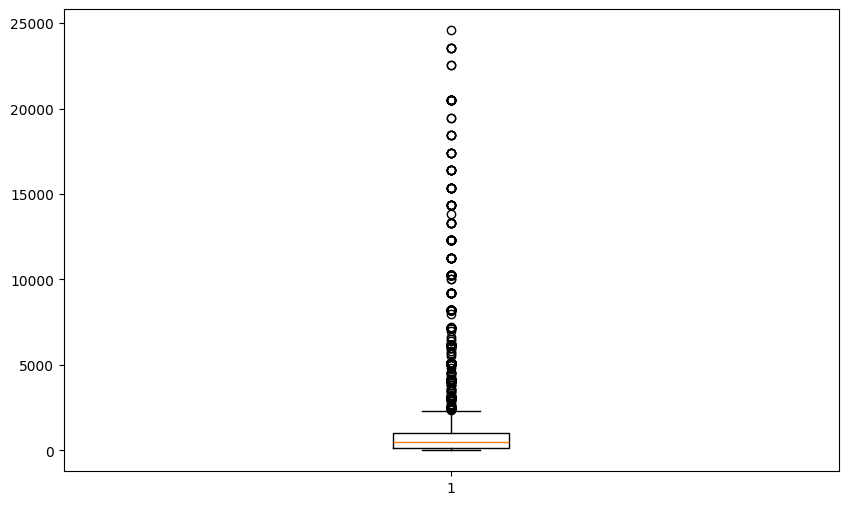

In [33]:
import matplotlib.pyplot as plt

pos_prop = pd.to_numeric(merged['GPU_mb'], errors='coerce').dropna()

plt.figure(figsize=(10, 6))
plt.boxplot(pos_prop.values)
plt.show()

In [45]:
import pandas as pd

# Load the version of the data that still has the raw numbers (tech_spec2.csv)
df = pd.read_csv('steam_final.csv')

# Define the threshold (32 GB in MB)
threshold_mb = 32 * 1024 

# Get the rows that exceed this threshold
ram_outliers = df[df['RAM_mb'] > threshold_mb]

# Display the findings
print(f"Found {len(ram_outliers)} rows with impossible RAM requirements.")
print(ram_outliers[['RAM_mb', 'cleaned']])

Found 0 rows with impossible RAM requirements.
Empty DataFrame
Columns: [RAM_mb, cleaned]
Index: []


In [46]:
import pandas as pd

# Define the threshold (5 GB in MB)
threshold_ghz =  5

# Get the rows that exceed this threshold
proc_outliers = df[df['processor_Ghz'] > threshold_mb]

# Display the findings
print(f"Found {len(proc_outliers)} rows with impossible proc requirements.")
print(proc_outliers[['processor_Ghz', 'cleaned']])

Found 0 rows with impossible proc requirements.
Empty DataFrame
Columns: [processor_Ghz, cleaned]
Index: []


In [47]:
import pandas as pd


# Define the threshold (100 GB in MB)
threshold_mb = 100 * 1024 

# Get the rows that exceed this threshold
storage_outliers = df[df['storage_mb'] > threshold_mb]

# Display the findings
print(f"Found {len(storage_outliers)} rows with impossible storage requirements.")
print(storage_outliers[['storage_mb', 'cleaned']])

Found 9 rows with impossible storage requirements.
       storage_mb                                            cleaned
7855     256000.0  Minimum: OS:  Microsoft® Windows® 7 / 8 Proces...
17090    125952.0  Minimum: OS:  Windows 123 Processor:  DIE1600 ...
20353    204800.0  Minimum: OS:  Windows 7 or more recent. Proces...
21265    122880.0  Minimum: OS:  Windows 7/8.1/10 (64-bit version...
23462    143360.0  Minimum: OS:  Windows 7 / 8 / 10 Processor:  C...
24995    307200.0  Minimum: OS:  Windows Vista, 7, 8, or 10 Proce...
25290    204800.0  Minimum: OS:  Windows 7 or newer: 32bit / 64bi...
25348    122880.0  Minimum: OS:  Windows 7 or newer: 32bit / 64bi...
25350    204800.0  Minimum: OS:  Windows 7 or newer: 32bit / 64bi...


In [48]:
import pandas as pd

# Define the threshold (16 GB in MB)
threshold_mb = 16 * 1024 

# Get the rows that exceed this threshold
GPU_outliers = df[df['GPU_mb'] > threshold_mb]

# Display the findings
print(f"Found {len(GPU_outliers)} rows with impossible storage requirements.")
print(GPU_outliers[['GPU_mb', 'cleaned']])

Found 38 rows with impossible storage requirements.
        GPU_mb                                            cleaned
419    17408.0  Minimum: OS:  Windows XP or later Processor:  ...
1185   20480.0  Minimum: OS: 32-bit:  Vista, Win 7, Win 8   Pr...
1764   20480.0  Minimum: OS:  Vista 64 bit/Win 7/Win 8 Process...
2498   18432.0  最低配置: 操作系统:  Windows 7 处理器:  2.3ghz 内存:  4 GB ...
3771   22528.0  Minimum: OS:  Windows 7 64-bit Processor:  Int...
5636   20480.0  Minimum: OS:  32-bit: Windows 7, Windows 8, Wi...
5767   20480.0  Minimum: OS:  Windows XP /Win7 /Win 8  (64-bit...
5850   20480.0  Minimum: OS:  Windows 7 Processor:  Intel i5-4...
7590   18432.0  Minimum: OS:  Windows 7 Processor:  fx-8350 Me...
7789   23552.0  Minimum: OS:  Win 7, 8, 10, 32bit Processor:  ...
7930   20480.0  Minimum: OS:  Windows 7/8/10 Processor:  Intel...
8263   17408.0  Minimum: OS:  Windows 7 (64-bit) or Newer. Doe...
8311   17408.0  Minimum: Requires a 64-bit processor and opera...
8910   20480.0  Minimum:

In [49]:
# Drop the GPU outliers
df = df.drop(GPU_outliers.index)

# Drop the storage outliers
df = df.drop(storage_outliers.index)

In [51]:
df.to_csv('steam_final.csv', index=False)

In [ ]:
final_clean = pd.read_csv('steam_final.csv')
# 2. Drop duplicates based on steam_appid
# 'keep=first' means it keeps the first row it finds and deletes subsequent ones
final_unique = final_clean.drop_duplicates(subset='appid', keep='first')

# 3. Print the results to see how many were removed
print(f"Original number of rows: {len(final_clean)}")
print(f"Number of rows after removing duplicates: {len(final_unique)}")

# 4. Save the deduplicated dataset
#final_unique.to_csv('tech_spec_deduplicated.csv', index=False)


Original number of rows: 54344
Number of rows after removing duplicates: 26868


In [42]:
final_unique.to_csv('steam_final.csv')